# Multi-scale

Can we link from our particle scale to the continuum?

In [ ]:
import yaml
import numpy as np
import matplotlib.pyplot as plt

import layer_models

In [ ]:
# This is extracted from the code we used to manage the big parameter sweep,
# so the input is a bit eccentric and split into things we (used to) sweep over
# and things we kept fixed for a whole sweep...

# Our 'sweep' parameters (highlighted point in Fig ):
case_name = 'test'
delta_t_icb = -10.0
delta_x_icb = 0.008125
this_i0 = None # Take it from the yaml

# Other model parameters as yaml:
input_data = """
f_layer_thickness : 200000
xfe_outer_core : 0.83
growth_prefactor : 150.0
i0 : 1.000000E-11
surf_energy : 1.08
wetting_angle : 5.0
number_of_analysis_points : 100
number_of_knots : 5
r_icb : 1221500
r_cmb : 3480000
gruneisen_parameter : 1.5
chemical_diffusivity : 1.000000E-09
kinematic_viscosity : 2.000000E-06
thermal_conductivity : 100.0
max_time : 1.0E20
hetrogeneous_radius : 10.0e-10
"""

input_params = yaml.load(input_data, yaml.CLoader)

In [ ]:
# Note that if BV freq is imaginary, or the case fails to run, output_data will be None...
cases_dict, output_data = layer_models.run_case(case_name, delta_t_icb, delta_x_icb, this_i0, input_params)

Dt = -10.0, delta_x = 0.008125, BV freq = 0.00022213856443482763, dT_liq = 75.86190718940907, dT_cond = 58.15753496004072


/Users/andreww/Code/slurry/flayer.py:516: RuntimeWarning: invalid value encountered in divide
  mean_particle_velocities[i] = np.mean((partial_densities * partial_velocities) /


Heat from crystalisation = 6.283611874717909 TW
Oxygen production rate = 2.7409723667471587e-08 Tg/s
Oxygen enrichment rate of outer core = 4.694942116025412e-05 wt. % Oxygen / Ga
maximum particle radius = 0.033483329504512764 m
maximum solid fraction = 1.368185474684128e-10
max_nucleation_rate = 8.931855885205271e-12


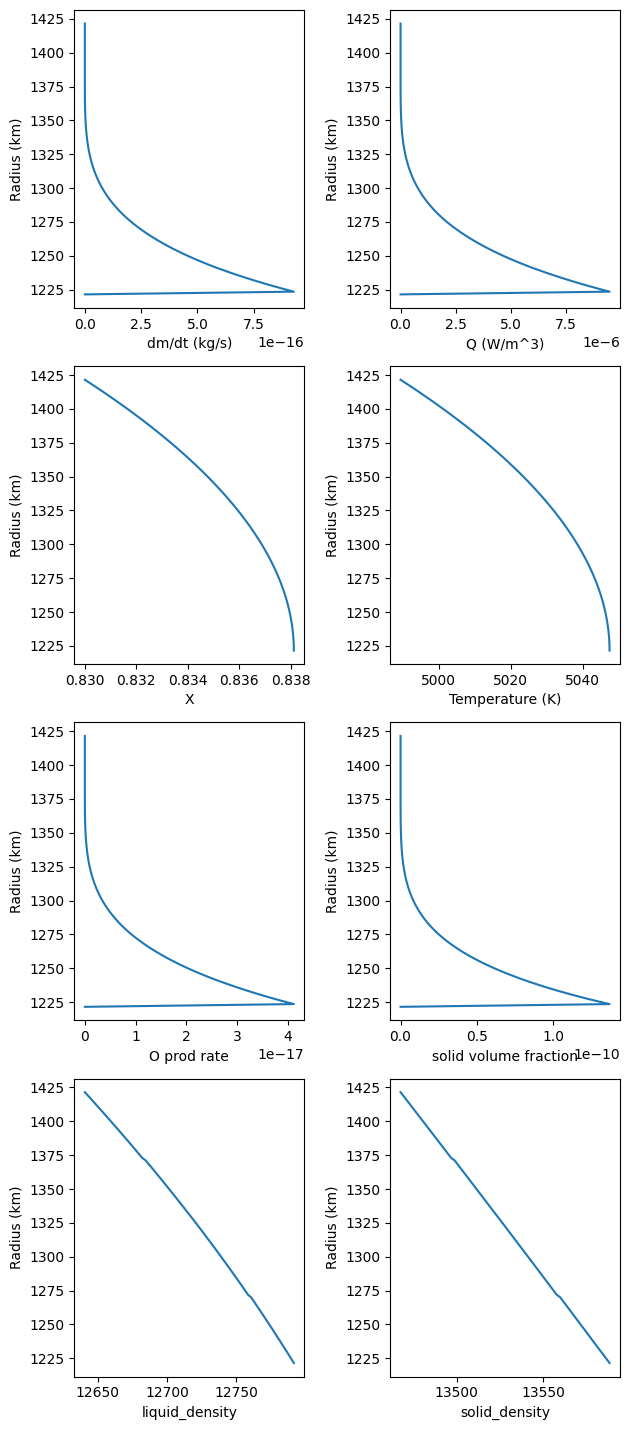

In [ ]:
fig, axs = plt.subplots(ncols=2, nrows=4, figsize=(6.4, 4.8*3))

axs[0,0].plot(output_data["profiles"].mass_fraction_solid_production_rate, output_data["profiles"].radius/1000.0)
axs[0,0].set_xlabel("dm/dt (kg/s)")
axs[0,0].set_ylabel("Radius (km)")

axs[0,1].plot(output_data["profiles"].heat_production_rate, output_data["profiles"].radius/1000.0)
axs[0,1].set_xlabel("Q (W/m^3)")
axs[0,1].set_ylabel("Radius (km)")

axs[1,0].plot(output_data["profiles"].liquid_composition, output_data["profiles"].radius/1000.0)
axs[1,0].set_xlabel("X")
axs[1,0].set_ylabel("Radius (km)")

axs[1,1].plot(output_data["profiles"].temperature, output_data["profiles"].radius/1000.0)
axs[1,1].set_xlabel("Temperature (K)")
axs[1,1].set_ylabel("Radius (km)")

axs[2,0].plot(output_data["profiles"].o_prod_rate, output_data["profiles"].radius/1000.0)
axs[2,0].set_xlabel("O prod rate")
axs[2,0].set_ylabel("Radius (km)")

axs[2,1].plot(output_data["profiles"].solid_volume_fraction, output_data["profiles"].radius/1000.0)
axs[2,1].set_xlabel("solid volume fraction")
axs[2,1].set_ylabel("Radius (km)")

axs[3,0].plot(output_data["profiles"].liquid_density, output_data["profiles"].radius/1000.0)
axs[3,0].set_xlabel("liquid_density")
axs[3,0].set_ylabel("Radius (km)")

axs[3,1].plot(output_data["profiles"].solid_density, output_data["profiles"].radius/1000.0)
axs[3,1].set_xlabel("solid_density")
axs[3,1].set_ylabel("Radius (km)")

fig.tight_layout()
plt.show()

In [ ]:
# EQ 2.1b

liquid_velocity = 0.0
liquid_velocity = 1.0E-16 # Needs to be positive (yay) and decreasing upwards (yay?)

lhs = (1.0 - output_data["profiles"].solid_volume_fraction) *  output_data["profiles"].liquid_density * liquid_velocity
lhs = np.gradient(lhs) 

rhs = output_data["profiles"].mass_fraction_solid_production_rate * -1.0


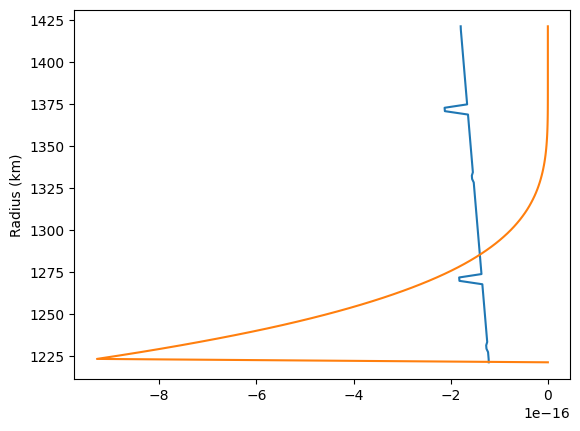

In [ ]:
fig, axs = plt.subplots()

axs.plot(lhs, output_data["profiles"].radius/1000.0)
axs.plot(rhs, output_data["profiles"].radius/1000.0)
axs.set_xlabel("")
axs.set_ylabel("Radius (km)")
plt.show()

In [ ]:
print(output_data["particle_histograms"].radius[2])
print(output_data["particle_histograms"].particle_velocity[2,:])
print(output_data["particle_histograms"].particle_size[2,:])
print(output_data["particle_histograms"].particle_density[2,:])
print(output_data["particle_histograms"].particle_volume_growth_rate[2,:])
print(output_data["particle_histograms"].particle_age[2,:])
# Probably need falling time... growth rate?

1225540.4040404041
[0.00000000e+00 0.00000000e+00 4.15732599e-03 6.73168510e-02
 8.89414337e-02 1.04272168e-01 1.16214315e-01 1.25896400e-01
 1.34018070e-01 1.41233734e-01 1.47468368e-01 1.53193317e-01
 1.58223089e-01 1.62833597e-01 1.66952571e-01 1.70716028e-01
 1.74379118e-01 1.77737046e-01 1.80592163e-01 1.83461282e-01
 1.86178097e-01 1.88675654e-01 1.90992608e-01 1.93394799e-01
 1.95488227e-01 1.97540557e-01 1.99383734e-01 2.01390509e-01
 2.02849366e-01 2.04466941e-01 2.06271971e-01 2.07671150e-01
 2.09083441e-01 2.10616909e-01 2.11926088e-01 2.13209975e-01
 2.14410075e-01 2.15763617e-01 2.16723275e-01 2.17901789e-01
 2.18905845e-01 2.19924906e-01 2.21029951e-01 2.21871538e-01
 2.22762575e-01 2.23751634e-01 2.24647810e-01 2.25418833e-01
 2.26101836e-01 2.27116808e-01 2.27849386e-01 2.28642003e-01
 2.29126602e-01 2.29890814e-01 2.30387337e-01 2.31103891e-01
 2.31817817e-01 2.32336266e-01 2.32747384e-01 2.33407287e-01
 2.33872419e-01 2.34526684e-01 2.35116313e-01 2.35469690e-01
 2.35

AttributeError: 'particle_histograms' object has no attribute 'particle_volume_growth_rate'